In [2]:
!pip install matplotlib deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 19.8 MB/s eta 0:00:00


In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms

In [4]:
# Define the number of locations and vehicles
num_locations = 20
locations = [(random.randint(0, 100), random.randint(0, 100)) for _ in range(num_locations)]
depot = (50, 50)
num_vehicles = 3

In [5]:
# Genetic Algorithm Setup
creator.create("FitnessMin", base.Fitness, weights=(-1.0, -1.0))
creator.create("Individual", list, fitness=creator.FitnessMin)

In [6]:
# Set up the individuals and population
toolbox = base.Toolbox()
toolbox.register("indices", random.sample, range(num_locations), num_locations)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.indices)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

In [7]:
# Fitness Function
def evalVRP(individual):
    total_dist = 0
    distances = []
    for i in range(num_vehicles):
        vehicle_route = [depot] + [locations[individual[j]] for j in range(i, len(individual), num_vehicles)] + [depot]
        dist = sum(np.linalg.norm(np.array(vehicle_route[j]) - np.array(vehicle_route[j+1])) for j in range(len(vehicle_route)-1))
        distances.append(dist)
        total_dist += dist
    total_dist = sum(distances)
    std_dev = np.std(distances)
    return (total_dist, std_dev)

toolbox.register("evaluate", evalVRP)

In [8]:
# Genetic Operators
toolbox.register("mate", tools.cxPartialyMatched)
toolbox.register("mutate", tools.mutShuffleIndexes, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

In [9]:
def plot_routes(individual, title="Routes"):
    plt.figure()
    for (x, y) in locations:
        plt.plot(x, y, 'bo')
    plt.plot(depot[0], depot[1], 'rs')

    for i in range(num_vehicles):
        vehicle_route = [depot] + [locations[individual[j]] for j in range(i, len(individual), num_vehicles)] + [depot]

        plt.plot(*zip(*vehicle_route), marker='o', label=f'Vehicle {i + 1}')

    plt.title(title)
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.legend()
    plt.show()

gen	nevals	avg    	min    
0  	300   	642.011	1.58811
1  	213   	611.401	2.08142
2  	243   	606.176	2.74155
3  	232   	596.229	1.72266
4  	233   	594.458	2.91403
5  	218   	588.395	5.7236 
6  	213   	586.823	1.62537
7  	233   	574.558	1.53685
8  	219   	570.109	2.66792
9  	209   	563.953	2.08541
10 	224   	562.418	3.31052
11 	230   	564.733	2.22317
12 	230   	564.633	7.51908
13 	217   	563.24 	5.6011 
14 	231   	567.32 	8.24101
15 	250   	568.814	1.29012
16 	238   	566.396	6.25735
17 	236   	567.648	1.73641
18 	225   	571.027	5.34914
19 	225   	558.351	2.08089
20 	209   	539.968	2.19112
21 	232   	532.348	2.19112
22 	237   	521.953	3.4269 
23 	217   	507.888	5.1025 
24 	227   	495.7  	1.34948
25 	246   	483.519	0.911731
26 	233   	465.015	4.23674 
27 	219   	453.466	2.17803 
28 	229   	446.181	7.56644 
29 	223   	445.705	3.55674 
30 	238   	443.507	5.65156 
31 	225   	436.609	7.30135 
32 	221   	433.5  	7.04706 
33 	243   	428.653	6.88492 
34 	232   	420.686	6.50077 
35 	244   	413.999

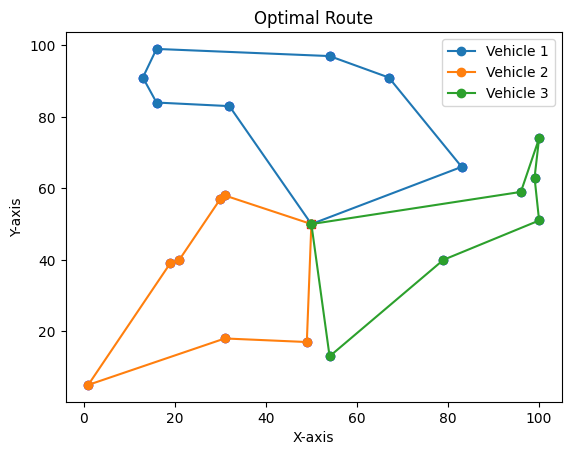

In [14]:
# Run the Genetic Algorithm
def main():
    random.seed(42)
    pop = toolbox.population(n=300)
    hof = tools.HallOfFame(1)

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("min", np.min)

    algorithms.eaSimple(pop, toolbox, 0.7, 0.2, 300, stats=stats, halloffame=hof)

    plot_routes(hof[0], "Optimal Route")
    return pop, stats, hof

if __name__ == "__main__":
    main()